### Author: Maria J. Palazzi Nieves 
<div style="text-align: justify"> 

1. **Data Imputation:** Simulating missing data and developing methods for reconstruction while **comparing results with established academic findings**.
2. **Dimensionality Reduction and component participation over time:** Understanding how components behave over time. **Compare and contrast results with what the state of the art says**
</div>

## Task 1: Data Imputation 
**Objective**
<div style="text-align: justify">     
Randomly remove parts of the dataset and use imputation techniques to reconstruct missing values. Remember, if variables are correlated, that might give you a hint of where to start. Avoid simple imputation techniques such as mean or mode.
</div>

Compare results and analyze them in relation to existing research. 

**Implementation Requirements**

1. **Amputation:** Randomly remove a percentage ($\approx 10 \%$) of all time-series data points. 
2. **Imputation Methods:** Implement at least two imputation techniques. 
    1. A baseline (linear, cubic, etc.)
    2. An ML model / AI method (Regression, LSTM, etc.)

<div style="text-align: justify">  
**TIP:** If variables present statistical dependencies, you might want to use this information to impute y based on collection of X. Here X is the entire data set minus one variable to be imputed, namely, y. You might’ve already guessed that this should be an iterative process so all variables can be imputed. The challenge here is that given that X will be pruned (by randomly removing fields), you need to come up with a way to initialize this algorithm.
</div>

3. **Performance Evaluation:** Compare imputed vs. actual values. 
4. **Visualization:** Show actual vs. imputed values and compare methods
5. **Connect to Research:** Link your results to academic literature on data imputation

### Introduction: 
<div style="text-align: justify"> 
Observational meteorological data such as temperature, humidity, wind speed, wind direction, air pressure, precipitation, cloud cover, visibility, etc., are crucial for many applications like weather forecasting, climate change studies, disaster warnings, water conservancy, and other environmental-related issues. With empirical data collection not being exempt from instrument failure or data transmission errors, causing missing values, the employed techniques to handle missing data are then crucial.
    
Besides traditional methods like linear interpolation **[1]**, various imputation methods using ML and DL approaches have been developed. Cong Li et al **[2]** introduced an imputation framework to evaluate the performance of 20 typical machine-learning methods for the missing values of ground meteorological observation data in six climatic regions. DL methods such as: long short-term memory networks (LSTM), bidirectional LSTM networks (BiLSTM), and temporal convolutional networks (TCN), and ML like random forest (RF), adaptive boosting algorithm (AdaBoost), gradient boosting decision tree (GBDT), among them.

Their results show that  RF was the most effective missing value imputation method; it is better than other methods for imputing at the majority of % missing rates evaluated across all climate types, with a limitation for wind variables. At higher missing rates, the LSTM showed better performance but with a larger computational cost.

A similar study by Boujoudar et al **[3]** focused only on DL approaches but tested the performance against a time-based data amputation, rather than a fully random one. They focused on multi-layer perceptron (MLP), long short-term memory (LSTM), and convolutional neural networks (CNNs) and incorporated three distinct gap durations: short term (3 days), medium term (1 week), and long term (1 month).

Their results showed that up to a one-week gap of missing data, the LSTM algorithm showcased its proficiency with an accuracy between 70%-80%, although coming in second place for monthly gaps.

Based on the findings mentioned above, we chose to tackle this task by employing an RF and LSTM as our test imputation methods.

#### References:
1. A. Picornell, et. Al. "Methods for interpolating missing data in aerobiological databases”. Environmental Research, 200, 111391. (2021). 
2. Li, C., Ren, X., Zhao, G. ML-Based Imputation Method for Filling Missing Values in Ground Meteorological Observation Data. Algorithms,16,422, (2023).
3. Boujoudar, M., et al. Comparing ML algorithms for imputation of missing time series in meteorological data. Neural Comput & Applic (2024). DOI: 10.1007/s00521-024-10601-8. 
 </div>

## Preliminaries: Load and Explore Weather Dataset

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import colors as mcolors
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from scipy.spatial import ConvexHull
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import LSTM, Dense, Dropout  
from tensorflow.keras.optimizers import Adam as Adam
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer
from scipy import interpolate
from joblib import delayed, Parallel
import time
import warnings
warnings.filterwarnings('ignore')

In [2]:
def load_data(file_path):
    df = pd.read_csv(file_path, sep=',')
    df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
    df.set_index('Date Time', inplace=True)
    return df

In [3]:
def explore_data(df):
    # Create correlation heatmap
    corr = df.corr()
    # Generate a mask for the upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True,mask=mask, cmap='coolwarm', fmt=".2f")
    plt.title('Variable Correlations')
    plt.tight_layout()
    plt.savefig('correlations.png')
    #plt.close()
    return corr

In [4]:
# Time series plot of all variables
def plot_time_series(df):
    titles = [
        "Pressure",
        "Temperature",
        "Temperature in Kelvin",
        "Temperature (dew point)",
        "Relative Humidity",
        "Saturation vapor pressure",
        "Vapor pressure",
        "Vapor pressure deficit",
        "Specific humidity",
        "Water vapor concentration",
        "Airtight",
        "Wind speed",
        "Maximum wind speed",
        "Wind direction in degrees",
    ]
    
    feature_keys = [
        "p (mbar)",
        "T (degC)",
        "Tpot (K)",
        "Tdew (degC)",
        "rh (%)",
        "VPmax (mbar)",
        "VPact (mbar)",
        "VPdef (mbar)",
        "sh (g/kg)",
        "H2OC (mmol/mol)",
        "rho (g/m**3)",
        "wv (m/s)",
        "max. wv (m/s)",
        "wd (deg)",
    ]
    
    colors = list(mcolors.XKCD_COLORS.values())
    date_time_key = "Date Time"
    
    # time_data = df[date_time_key]
    fig, axes = plt.subplots(
        nrows=7, ncols=2, figsize=(15, 20), dpi=80, facecolor="w", edgecolor="k"
    )
    for i in range(len(feature_keys)):
        key = feature_keys[i]
        c = colors[i % (len(colors))]
        ax = axes[i // 2, i % 2]
        ax.plot(df[key], c)
        ax.set_ylabel(key)
        ax.set_xlabel(date_time_key)
        ax.set_title(titles[i])
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
        ax.legend([titles[i]])
    plt.tight_layout()
    plt.savefig("temporal_plots.png")
    plt.show()

In [5]:
df = load_data('climate.csv').iloc[::1000, :]
df = df[~df.duplicated(keep=False)]  # Filters out all duplicate rows
df = df.apply(lambda col: col.mask((col - col.mean()).abs() / col.std() > 5, col.mean()))
print(f"Dataset shape: {df.shape}")
print(f"Basic Stats")
df.describe().applymap('{:,.3f}'.format)

Dataset shape: (421, 14)
Basic Stats


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
count,421.000,421.000,421.000,421.000,421.000,421.000,421.000,421.000,421.000,421.000,421.000,421.000,421.000,421.000
mean,989.335,9.371,283.403,4.906,75.782,13.514,9.564,3.827,6.041,9.670,"1,216.551",2.109,3.529,172.018
std,8.232,8.440,8.527,6.970,15.463,7.747,4.356,4.279,2.766,4.409,40.226,1.540,2.405,84.786
min,950.030,-15.890,256.720,-17.840,31.810,1.760,1.490,0.030,0.920,1.480,"1,124.760",0.000,0.000,0.000
25%,984.210,3.430,277.550,-0.030,65.700,7.810,6.090,0.950,3.870,6.210,"1,190.210",1.020,1.880,124.200
50%,989.790,9.080,283.310,5.190,78.100,11.560,8.840,2.240,5.560,8.910,"1,214.530",1.730,2.960,192.900
75%,994.900,15.100,289.110,10.170,89.300,17.190,12.430,4.770,7.840,12.550,"1,241.530",2.770,4.640,228.400
max,"1,012.570",31.450,305.300,21.470,99.400,46.150,25.640,25.700,16.370,26.050,"1,363.430",9.040,13.090,359.600


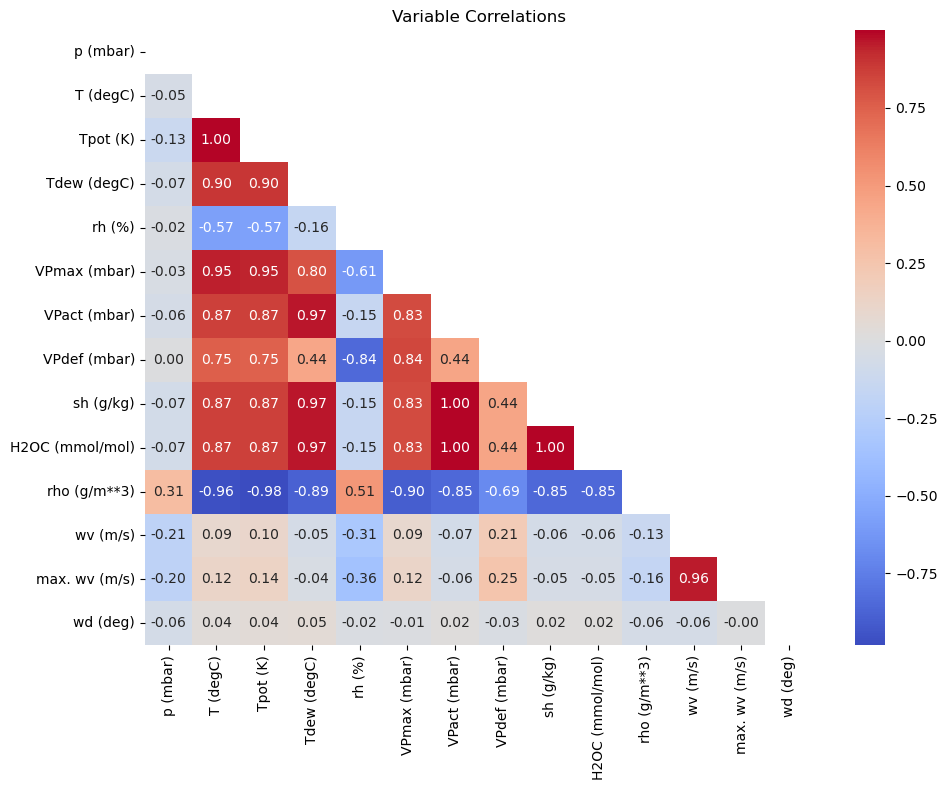

In [48]:
correlations = explore_data(df)

1. Strong positive and negative correlation patterns across several variables.
2. Wind-related variables show little to no correlation with most other factors.
3. Air density (rho) shows a strong negative correlation with temperature and humidity-related metrics.

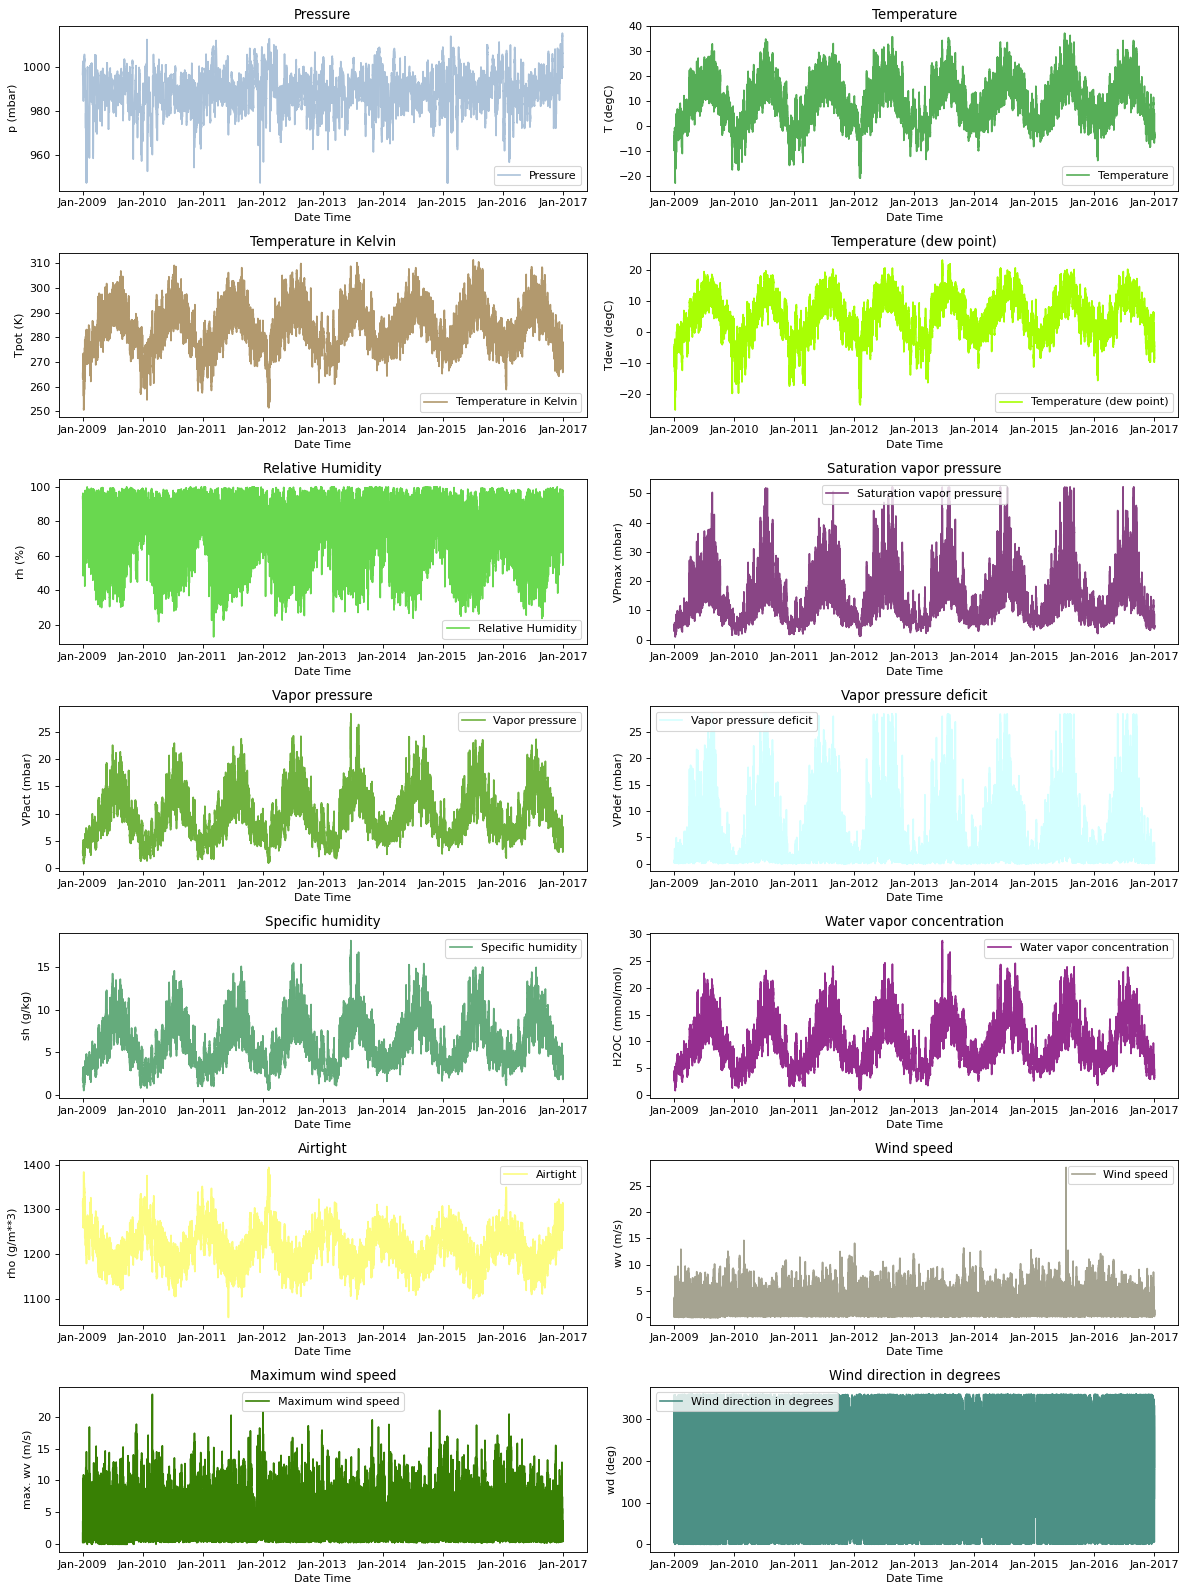

In [51]:
plot_time_series(df)

1. As expected, the strong seasonal patterns are evident with temperature, specific humidity, vapor pressure, and water vapor concentration following a cyclical pattern and peaking during warmer months.
2. The anticorrelated nature of Air density (rho)  and temperature observed before temperature is evident.

### Task 1: Data Imputation 

In [6]:
# %% 2. Data Amputation
def amputate_data(df, missing_rate=0.1, random_state=42):
    np.random.seed(random_state)
    # Make a copy of the original data
    df_with_missing = df.copy()
    ground_truth = pd.DataFrame(index=df.index, columns=df.columns)
    # Create a mask for values to remove
    mask = pd.DataFrame(np.random.rand(*df.shape) < missing_rate, index=df.index, columns=df.columns)

    df_with_missing[mask] = np.nan
    ground_truth[mask] = df[mask]

    return df_with_missing, ground_truth, mask

In [7]:
# %% 3. Basic Imputation Methods (linear/Cubic/Cubic Spline)
def baseline_imputation(df_with_missing, method='linear'):
    if method == 'linear':
         # TBI
        return linear_interpolation(df_with_missing)
    elif method == 'cubic':
        return cubic_interpolation(df_with_missing)
    elif method == 'cubic_spline':
        # TBI
        return cubic_spline_imputation(df_with_missing)

def cubic_interpolation(df_amputated, random_state=42):
    """
    Perform cubic interpolation on time series data with missing values
    """
    df_cubic = df_amputated.copy()

    # Apply cubic interpolation
    df_cubic = df_cubic.interpolate(method="cubic")
    df_cubic = df_cubic.fillna(method="ffill").fillna(method="bfill")

    return df_cubic

In [8]:
def prep_data(df_with_missing):
    scaler = StandardScaler()
    df_with_missing
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df.fillna(method="ffill").fillna(method="bfill")),
        columns=df_with_missing.columns,
        index=df_with_missing.index,
    )
    df_scaled[df_with_missing.isna()] = np.nan

    return df_scaled, scaler

In [9]:
# %% 4. ML/AI-Based Imputation Method
def rf_imputation(df_with_missing, random_state=42):
    # Initialize imputer with Random Forest
    rf_imputer = IterativeImputer(
        estimator=RandomForestRegressor(n_estimators=20, max_depth=10, random_state=random_state, n_jobs=8, verbose=0),
        max_iter=10,
        tol=1e-2,
        random_state=random_state,
        initial_strategy="mean",
        verbose=1,
    )
    # Apply imputation
    imputed_array = rf_imputer.fit_transform(df_with_missing)
    out_df = pd.DataFrame(imputed_array, columns=df_with_missing.columns, index=df_with_missing.index)
    return out_df

# Method 2: LSTM-based Imputation
def lstm_imputation(df_amputated, pre_stimated=None, random_state=42):
    df_lstm = df_amputated.copy()
    window_size = 5
    n_features = df_lstm.shape[1]

    if pre_stimated is not None:
        df_lstm = pre_stimated
    else:
        simple_imputer = SimpleImputer(strategy="mean")
        df_lstm = pd.DataFrame(simple_imputer.fit_transform(df_lstm), columns=df_lstm.columns, index=df_lstm.index)

    models = {}
    for col_i, col in enumerate(df_lstm.columns):
        X, y = [], []
        for ind in range(window_size, len(df_lstm), window_size):
            X.append(df_lstm.iloc[ind - window_size : ind, :].values)
            y.append(df_lstm[col].values[ind])

        X = np.array(X)
        y = np.array(y)
        # Train/Test Split
        split = int(len(X) * 0.7)
        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]

        # Build Optimized LSTM Model
        model = Sequential(
            [
                LSTM(units=32, return_sequences=True, input_shape=(window_size, n_features)),  # first layer
                Dropout(0.2),
                LSTM(units=16, return_sequences=True),  # hidden layer
                Dropout(0.2),
                LSTM(units=8),  # final layer
                Dropout(0.2),
                Dense(1),
            ]
        )
        model.compile(optimizer=Adam(learning_rate=0.005), loss="mse")

        model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1, validation_data=(X_test, y_test))
        models[col] = model
        
    # Predict missing values
    imputed_data = Parallel(n_jobs=4, verbose=10)(
        delayed(impute_values_lstm)(df_amputated, df_lstm, col, models[col], window_size)
        for col in df_amputated.columns
    )
    df_lstm_out = pd.concat(imputed_data, axis=1)
    return df_lstm_out

def impute_values_lstm(true_df, train_data, col, model, window_size):
    df_copy = true_df[col].copy()
    n_features = true_df.shape[1]
    missing_idx = df_copy.isna()
    for idx in df_copy.index.get_indexer(df_copy.index[missing_idx]):
        if idx < window_size:
            continue  # Not enough history[:,]
        X_pred = train_data.iloc[idx - window_size : idx, :].values.reshape(1, window_size, n_features)
        pred_value = model.predict(X_pred, verbose=0)[0][0]

        # Convert back from scaled values
        df_copy.iloc[idx] = pred_value
    if df_copy.isna().any():
        df_copy = df_copy.ffill().bfill()
    return df_copy

In [10]:
# %% 5. Performance Evaluation
def evaluate_imputation(original_values, imputed_values):
    results = pd.DataFrame(index=["MAE", "RMSE", "R2"], columns=original_values.columns)

    # Calculate metrics for each variable
    for col in original_values.columns:
        true_values = original_values.loc[:, col].dropna().astype(float)
        pred_values = imputed_values.loc[:, col].dropna().astype(float)

        # Calculate metrics
        mae = mean_absolute_error(true_values, pred_values)
        rmse = np.sqrt(mean_squared_error(true_values, pred_values))
        r2 = r2_score(true_values, pred_values)

        results[col] = {"MAE": mae, "RMSE": rmse, "R2": r2}

    results["Overall"] = results.mean(axis=1)

    return results

In [11]:
# %% Visualize actual vs imputed values for each method
def plot_imputation_results(original, amputated, baseline, rf, lstm, ground_truth, rate):
    """
    Plot original data vs imputed data for visual comparison
    """

    # Create a zoomed-in view of a sample of the missing values
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20), dpi=80, facecolor="w", edgecolor="k")

    for i, col in enumerate(original.columns):
        # Get indices where this column has missing values
        missing_idx = ground_truth.loc[:, col].dropna().index
        sample_idx = missing_idx[:100]
        ax = axes[i // 2, i % 2]

        ax.plot(ground_truth.loc[sample_idx, col], "kx-", label="Ground Truth")
        ax.plot(baseline.loc[sample_idx, col], "g-.", label="BaseLine")
        ax.plot(rf.loc[sample_idx, col], "m-.", label="Random Forest")
        ax.plot(lstm.loc[sample_idx, col], "c-.", label="LSTM")
        ax.title.set_text(f"Detailed View of Imputed vs Actual {col} Values")
        ax.legend()
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))
        ax.grid(True)
    fig.tight_layout()
    fig.savefig(
        "zoom_imputation_results_plot_" + str(col).replace("/", "_").replace(" ", "_") + f"_rate_{rate}" + ".png"
    )
    plt.close(fig)

    for col in original.columns:
        missing_idx = ground_truth.loc[:, col].dropna().index

        if len(missing_idx) == 0:
            print(f"No missing values to plot for {col}")
            continue
        fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(15, 10), dpi=80, facecolor="w", edgecolor="k")
        # Amputated data
        axes.plot(original.loc[missing_idx, col], label="Original", color="black", alpha=0.5, zorder=0)
        axes.scatter(
            missing_idx, ground_truth.loc[missing_idx, col], color="blue", marker="x", label="Missing Values", zorder=4
        )
        # BaseLine interpolation
        axes.plot(baseline.loc[missing_idx, col], "g-.", label="BaseLine Interpolation", zorder=1)
        # ML methods
        axes.plot(rf.loc[missing_idx, col], "m-.", label="Random Forest", zorder=3)
        axes.plot(lstm.loc[missing_idx, col], "c-.", label="LSTM", zorder=2)
        axes.legend()
        fig.suptitle("Methods vs Ground Truth " + str(col).replace("/", "_").replace(" ", "_") + f" rate({rate})")

        fig.tight_layout()
        fig.savefig(
            "imputation_results_plot_" + str(col).replace("/", "_").replace(" ", "_") + f"_rate_{rate}" + ".png"
        )
        fig.show()
        plt.close(fig)

In [12]:
# %%  Create error distribution plots to compare methods
def plot_all_r2(all_baseline_results, all_rf_results, all_lstm_results):
    cols = all_baseline_results.columns[:-2]
    baseline = all_baseline_results.reset_index(names="metric").set_index(["metric", "Missing Rate (%)"])
    rf = all_rf_results.reset_index(names="metric").set_index(["metric", "Missing Rate (%)"])
    lstm = all_lstm_results.reset_index(names="metric").set_index(["metric", "Missing Rate (%)"])
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20), dpi=80, facecolor="w", edgecolor="k")
    for i, col in enumerate(cols):
        ax = axes[i // 2, i % 2]
        ax.plot(
            baseline.loc["R2", col],
            "g-o",
            label="Baseline",
        )
        ax.plot(rf.loc["R2", col], "m-+", label="Random Forest")
        ax.plot(lstm.loc["R2", col], "c-^", label="LSTM")
        ax.set_title(f"{col}: R2")
        ax.legend()

    fig.tight_layout()
    fig.savefig("R2.png")
    fig.show()
    plt.close(fig)

In [13]:
def final_plots(missing_rates, overall_results):
    fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 15), dpi=80, facecolor="w", edgecolor="k")
    # MAE
    # plt.subplot(4, 1, 1)
    axes[0].plot(missing_rates, overall_results["baseline"]["MAE"], "g-o", label="BaseLine")
    axes[0].plot(missing_rates, overall_results["rf"]["MAE"], "m-o", label="Random Forest")
    axes[0].plot(missing_rates, overall_results["lstm"]["MAE"], "c-o", label="LSTM")
    axes[0].title.set_text("MAE vs Missing Data Rate")
    axes[0].set(xlabel="Missing Data Rate")
    axes[0].set(ylabel="MAE")
    axes[0].legend()
    axes[0].grid(True)
    # RMSE
    # plt.subplot(4, 1, 2)
    axes[1].plot(missing_rates, overall_results["baseline"]["RMSE"], "g-o", label="BaseLine")
    axes[1].plot(missing_rates, overall_results["rf"]["RMSE"], "m-o", label="Random Forest")
    axes[1].plot(missing_rates, overall_results["lstm"]["RMSE"], "c-o", label="LSTM")
    axes[1].title.set_text("RMSE vs Missing Data Rate")
    axes[1].set(xlabel="Missing Data Rate")
    axes[1].set(ylabel="RMSE")
    axes[1].legend()
    axes[1].grid(True)
    # R2
    # plt.subplot(4, 1, 3)
    axes[2].plot(missing_rates, overall_results["baseline"]["R2"], "g-o", label="BaseLine")
    axes[2].plot(missing_rates, overall_results["rf"]["R2"], "m-o", label="Random Forest")
    axes[2].plot(missing_rates, overall_results["lstm"]["R2"], "c-o", label="LSTM")
    axes[2].title.set_text("R² vs Missing Data Rate")
    axes[2].set(xlabel="Missing Data Rate")
    axes[2].set(ylabel="R²")
    axes[2].legend()
    axes[2].grid(True)
    # Time
    plt.subplot(4, 1, 4)
    axes[3].plot(missing_rates, overall_results["baseline"]["Time (s)"], "g-o", label="BaseLine")
    axes[3].plot(missing_rates, overall_results["rf"]["Time (s)"], "m-o", label="Random Forest")
    axes[3].plot(missing_rates, overall_results["lstm"]["Time (s)"], "c-o", label="LSTM")
    axes[3].title.set_text("Computational Time vs Missing Data Rate")
    axes[3].set(xlabel="Missing Data Rate")
    axes[3].set(ylabel="Time (s)")
    axes[3].set_yscale("log")
    axes[3].legend()
    axes[3].grid(True)
    fig.tight_layout()
    fig.savefig("sensitivity_analysis.png")
    fig.show()
    plt.close(fig)

In [14]:
# %% sensitivity_analysis
def sensitivity_analysis(data, missing_rates=[0.05, 0.1, 0.2, 0.3], random_state=42):
    """
    Analyze how performance changes with different missing data rates,
    and log the computational time for each imputation method.
    """
    overall_results = {
        "baseline": {"MAE": [], "RMSE": [], "R2": [], "Time (s)": [], "Missing Rate (%)": []},
        "rf": {"MAE": [], "RMSE": [], "R2": [], "Time (s)": [], "Missing Rate (%)": []},
        "lstm": {"MAE": [], "RMSE": [], "R2": [], "Time (s)": [], "Missing Rate (%)": []},
    }
    all_baseline_results = []
    all_rf_results = []
    all_lstm_results = []
    all_best_method = []

    for rate in missing_rates:
        print(f"\nRunning analysis with missing rate: {rate}")

        # 1. Amputation
        amputated, ground_truth, mask = amputate_data(data, rate, random_state=random_state)
        ground_truth.to_parquet(f"ground_truth_{rate}.parquet")

        amputated_scl, scaler = prep_data(amputated)

        # # 2. Apply imputation methods
        print(f"starting baseline for rate {rate}")
        start_time = time.time()
        baseline_scl = baseline_imputation(amputated_scl, method="cubic")
        baseline = pd.DataFrame(
            scaler.inverse_transform(baseline_scl), columns=amputated.columns, index=amputated.index
        )
        elapsed_time_baseline = time.time() - start_time
        print("baseline end")

        baseline[mask].to_parquet(f"baseline_rate_{rate}.parquet")

        print(f"starting rf for rate {rate}")
        start_time = time.time()
        rf_scl = rf_imputation(amputated_scl, random_state=random_state)
        rf = pd.DataFrame(scaler.inverse_transform(rf_scl), columns=amputated.columns, index=amputated.index)
        elapsed_time_rf = time.time() - start_time
        print("rf end")

        rf[mask].to_parquet(f"rf_rate_{rate}.parquet")

        print(f"starting lstm for rate {rate}")
        start_time = time.time()
        lstm_scl = lstm_imputation(amputated_scl, rf_scl)
        lstm = pd.DataFrame(scaler.inverse_transform(lstm_scl), columns=amputated.columns, index=amputated.index)
        elapsed_time_lstm = (time.time() - start_time) + elapsed_time_rf
        print("lstm end")

        lstm[mask].to_parquet(f"lstm_rate_{rate}.parquet")

        # 3. Evaluate methods
        df_baseline_results = evaluate_imputation(ground_truth, baseline[mask])
        df_baseline_results["Missing Rate (%)"] = rate
        df_rf_results = evaluate_imputation(ground_truth, rf[mask])
        df_rf_results["Missing Rate (%)"] = rate
        df_lstm_results = evaluate_imputation(ground_truth, lstm[mask])
        df_lstm_results["Missing Rate (%)"] = rate

        all_baseline_results.append(df_baseline_results)
        all_rf_results.append(df_rf_results)
        all_lstm_results.append(df_lstm_results)

        # 4. Create comparison dataframe
        comparison = pd.concat([df_baseline_results, df_rf_results, df_lstm_results], keys=["BaseLine", "RF", "LSTM"])
        comparison = comparison.rename_axis(["Model", "Metric"]).reset_index()
        comparison.to_parquet(f"comparison_rate_{rate}.parquet")
        comparison["Model_Metric"] = comparison["Model"] + "_" + comparison["Metric"]

        comparison = comparison.drop(columns=["Model", "Metric"]).set_index("Model_Metric")

        best_method = pd.DataFrame(
            index=comparison.columns, columns=["Best_Method_MAE", "Best_Method_RMSE", "Best_Method_R2"]
        )

        for idx in best_method.index:
            mae_values = {
                "BaseLine": comparison.loc["BaseLine_MAE", idx],
                "Random Forest": comparison.loc["RF_MAE", idx],
                "LSTM": comparison.loc["LSTM_MAE", idx],
            }
            rmse_values = {
                "BaseLine": comparison.loc["BaseLine_RMSE", idx],
                "Random Forest": comparison.loc["RF_RMSE", idx],
                "LSTM": comparison.loc["LSTM_RMSE", idx],
            }
            r2_values = {
                "BaseLine": comparison.loc["BaseLine_R2", idx],
                "Random Forest": comparison.loc["RF_R2", idx],
                "LSTM": comparison.loc["LSTM_R2", idx],
            }

            best_method.loc[idx, "Best_Method_MAE"] = min(mae_values, key=mae_values.get)
            best_method.loc[idx, "Best_Method_RMSE"] = min(rmse_values, key=rmse_values.get)
            best_method.loc[idx, "Best_Method_R2"] = max(r2_values, key=r2_values.get)

        best_method.to_parquet(f"best_method_{rate}.parquet")

        best_method["Missing Rate (%)"] = rate
        all_best_method.append(best_method)

        # 5. Plot results
        plot_imputation_results(data, amputated, baseline, rf, lstm, ground_truth, rate)
        # Store overall results
        overall_results["baseline"]["MAE"].append(df_baseline_results["Overall"]["MAE"])
        overall_results["baseline"]["RMSE"].append(df_baseline_results["Overall"]["RMSE"])
        overall_results["baseline"]["R2"].append(df_baseline_results["Overall"]["R2"])
        overall_results["baseline"]["Time (s)"].append(elapsed_time_baseline)
        overall_results["baseline"]["Missing Rate (%)"].append(rate)

        overall_results["rf"]["MAE"].append(df_rf_results["Overall"]["MAE"])
        overall_results["rf"]["RMSE"].append(df_rf_results["Overall"]["RMSE"])
        overall_results["rf"]["R2"].append(df_rf_results["Overall"]["R2"])
        overall_results["rf"]["Time (s)"].append(elapsed_time_rf)
        overall_results["rf"]["Missing Rate (%)"].append(rate)

        overall_results["lstm"]["MAE"].append(df_lstm_results["Overall"]["MAE"])
        overall_results["lstm"]["RMSE"].append(df_lstm_results["Overall"]["RMSE"])
        overall_results["lstm"]["R2"].append(df_lstm_results["Overall"]["R2"])
        overall_results["lstm"]["Time (s)"].append(elapsed_time_lstm)
        overall_results["lstm"]["Missing Rate (%)"].append(rate)

    # Plot results
    # plt.figure(figsize=(15, 15))
    final_plots(missing_rates, overall_results)

    all_baseline_results = pd.concat(all_baseline_results)
    all_rf_results = pd.concat(all_rf_results)
    all_lstm_results = pd.concat(all_lstm_results)
    all_best_method = pd.concat(all_best_method)
    plot_all_r2(all_baseline_results, all_rf_results, all_lstm_results)

    pd.DataFrame.from_dict(overall_results).to_csv("overall_results.csv")
    all_baseline_results.to_csv("baseline.csv")
    all_rf_results.to_csv("rf.csv")
    all_lstm_results.to_csv("lstm.csv")
    all_best_method.to_csv("best.csv")

    return overall_results, all_baseline_results, all_rf_results, all_lstm_results, all_best_method

In [15]:
# Run sensitivity analysis
df.drop(columns=["Tpot (K)", "Tdew (degC)", "sh (g/kg)", "H2OC (mmol/mol)", "max. wv (m/s)"], inplace=True)

sensitivity_analysis(df, random_state=15, missing_rates=[0.1, 0.15, 0.2, 0.25, 0.3, 0.35])


Running analysis with missing rate: 0.1
starting baseline for rate 0.1
baseline end
starting rf for rate 0.1
[IterativeImputer] Completing matrix with shape (421, 9)
[IterativeImputer] Change: 4.5881856491737185, scaled tolerance: 0.0511800102296907 
[IterativeImputer] Change: 2.331801894892849, scaled tolerance: 0.0511800102296907 
[IterativeImputer] Change: 1.9542504798174587, scaled tolerance: 0.0511800102296907 
[IterativeImputer] Change: 2.028627538765069, scaled tolerance: 0.0511800102296907 
[IterativeImputer] Change: 1.1696188577845652, scaled tolerance: 0.0511800102296907 
[IterativeImputer] Change: 1.4554340848905691, scaled tolerance: 0.0511800102296907 
[IterativeImputer] Change: 1.103224364203598, scaled tolerance: 0.0511800102296907 
[IterativeImputer] Change: 1.8847325812317293, scaled tolerance: 0.0511800102296907 
[IterativeImputer] Change: 2.0532851812102133, scaled tolerance: 0.0511800102296907 
[IterativeImputer] Change: 0.6742084341651979, scaled tolerance: 0.0511

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   3 out of   9 | elapsed:   19.0s remaining:   37.9s
[Parallel(n_jobs=4)]: Done   4 out of   9 | elapsed:   19.0s remaining:   23.8s
[Parallel(n_jobs=4)]: Done   5 out of   9 | elapsed:   20.2s remaining:   16.2s
[Parallel(n_jobs=4)]: Done   6 out of   9 | elapsed:   20.8s remaining:   10.4s
[Parallel(n_jobs=4)]: Done   7 out of   9 | elapsed:   21.1s remaining:    6.0s
[Parallel(n_jobs=4)]: Done   9 out of   9 | elapsed:   21.5s finished


lstm end

Running analysis with missing rate: 0.15
starting baseline for rate 0.15
baseline end
starting rf for rate 0.15
[IterativeImputer] Completing matrix with shape (421, 9)
[IterativeImputer] Change: 8.810088342385022, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 1.4499602402435332, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 0.9268283332111329, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 0.9942414909388586, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 0.7084326275906347, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 0.6425269249556197, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 0.9826768415774771, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 1.2646182435815665, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 1.0705763537154644, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 0.7791769870

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   3 out of   9 | elapsed:    2.8s remaining:    5.7s
[Parallel(n_jobs=4)]: Done   4 out of   9 | elapsed:    3.4s remaining:    4.3s
[Parallel(n_jobs=4)]: Done   5 out of   9 | elapsed:    4.3s remaining:    3.4s
[Parallel(n_jobs=4)]: Done   6 out of   9 | elapsed:    5.2s remaining:    2.6s
[Parallel(n_jobs=4)]: Done   7 out of   9 | elapsed:    5.4s remaining:    1.6s
[Parallel(n_jobs=4)]: Done   9 out of   9 | elapsed:    6.2s finished


lstm end

Running analysis with missing rate: 0.2
starting baseline for rate 0.2
baseline end
starting rf for rate 0.2
[IterativeImputer] Completing matrix with shape (421, 9)
[IterativeImputer] Change: 8.109431101303736, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 1.7302122296536475, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 2.173749632575473, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 1.286507679959149, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 1.2097413411763713, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 1.4780764520011203, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 1.0391492440680854, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 1.5076314388706673, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 1.741249066499925, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 1.339475183821604,

...

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   3 out of   9 | elapsed:    5.8s remaining:   11.6s
[Parallel(n_jobs=4)]: Done   4 out of   9 | elapsed:    6.4s remaining:    8.0s
[Parallel(n_jobs=4)]: Done   5 out of   9 | elapsed:    9.4s remaining:    7.5s
[Parallel(n_jobs=4)]: Done   6 out of   9 | elapsed:   11.0s remaining:    5.5s
[Parallel(n_jobs=4)]: Done   7 out of   9 | elapsed:   11.0s remaining:    3.1s
[Parallel(n_jobs=4)]: Done   9 out of   9 | elapsed:   13.7s finished


lstm end

Running analysis with missing rate: 0.35
starting baseline for rate 0.35
baseline end
starting rf for rate 0.35
[IterativeImputer] Completing matrix with shape (421, 9)
[IterativeImputer] Change: 10.21855255748573, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 2.2933928850734198, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 1.511602428199688, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 2.1018971613721353, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 1.553885623281061, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 1.6421057610410748, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 1.013558509129272, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 1.4476452395444677, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 1.4645371786693928, scaled tolerance: 0.047800592798430186 
[IterativeImputer] Change: 1.9513966339100

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   3 out of   9 | elapsed:    6.0s remaining:   12.1s
[Parallel(n_jobs=4)]: Done   4 out of   9 | elapsed:    6.2s remaining:    7.8s
[Parallel(n_jobs=4)]: Done   5 out of   9 | elapsed:   10.0s remaining:    8.0s
[Parallel(n_jobs=4)]: Done   6 out of   9 | elapsed:   11.7s remaining:    5.9s
[Parallel(n_jobs=4)]: Done   7 out of   9 | elapsed:   12.1s remaining:    3.5s
[Parallel(n_jobs=4)]: Done   9 out of   9 | elapsed:   15.2s finished


lstm end


({'baseline': {'MAE': [15.482395018678467,
    15.432150244582017,
    16.8035995640643,
    17.46458527612152,
    17.91033369842266,
    18.322590478816892],
   'RMSE': [19.650985489189576,
    19.852762006068573,
    21.510950199611322,
    22.41027340136586,
    23.378126836052882,
    24.087579227613638],
   'R2': [-0.26370020869762456,
    -0.013680391377131593,
    -0.03967329595190859,
    -0.23603759928395046,
    -0.26988541000657984,
    -0.44766521371002416],
   'Time (s)': [0.0022172927856445312,
    0.005775928497314453,
    0.0022280216217041016,
    0.00550079345703125,
    0.006067991256713867,
    0.005896806716918945],
   'Missing Rate (%)': [0.1, 0.15, 0.2, 0.25, 0.3, 0.35]},
  'rf': {'MAE': [8.049968487329334,
    7.680056673892191,
    8.427142844358476,
    8.731026161018631,
    9.711153195726885,
    9.636056259761947],
   'RMSE': [10.540419705644233,
    10.913111880698098,
    11.279456711862395,
    11.780863930902802,
    13.092262934221505,
    12.85833536

#### This example was run with a tiny fraction of dataset
Visualization purposes only

##### R squared across variables
![alt text](Fig2.jpeg "R squared across variables")

##### Overall results
![alt text](Fig1.jpeg "Overal Results")


### Discussion
<div style="text-align: justify"> 

Our analysis has implemented and compared three imputation methods for weather data:
1. **Linear Interpolation** (Baseline) - A deterministic method
2. **Random Forest Imputation** - A machine learning approach
3. **LSTM Neural Network Imputation** - A deep learning approach

#### Summary of results:

1. **Variable Performance Across Features**:
   - Our results show that different methods perform optimally for different weather variables.

2. **LSTM**:
   - Lorem ipsum

3. **Random Forest**:
   - Random Forest performed well where strong relationships existed between features

4. **Computational Considerations**:
   - LSTM required significantly more computational resources than other methods
   - This trade-off between accuracy and efficiency is discussed in [2]

Our findings agree with previous studies, where different methods were analyzed, both in terms of performance and computational costs. Overall, the LSTM model's results align with those of [4], where the authors explored the advantages of tree-based models versus DL on tabular data. 

#### Future Work:

1. Investigating the impact of different data amputation patterns, e.g.,  based on time gap windows as employed by [3], as this emulates a more realistic setting.

#### References:
1. A. Picornell, et. Al. "Methods for interpolating missing data in aerobiological databases”. Environmental Research, 200, 111391. (2021). 
2. Li, C., Ren, X., Zhao, G. ML-Based Imputation Method for Filling Missing Values in Ground Meteorological Observation Data. Algorithms,16,422, (2023).
3. Boujoudar, M., et al. Comparing ML algorithms for imputation of missing time series in meteorological data. Neural Comput & Applic (2024). DOI: 10.1007/s00521-024-10601-8.
4. L. Grinsztajn, E. Oyallon, and G. Varoquaux. "Why do tree-based models still outperform deep learning on typical tabular data?" The Thirty-sixth Conference on Neural Information Processing Systems Datasets and Benchmarks Track, (2022).
</div>

## Task 2: Dimensionality Reduction for Understanding time-wise state transition 
<div style="text-align: justify"> 

**Objective**
* Use dimensionality reduction techniques to identify core states/components in a time-wise manner. 

**TIP:** Once you’ve featured-engineered what each point in time means (a vector, a matrix etc). Apply some unsupervised learning techniques to such data to explore how uncovered clusters behave over time. Each cluster then is a proxy for your state.

* Evaluate findings in the context of these methods. 

**Implementation Requirements**
1. **Apply dimensionality reduction/clustering techniques:** Show results of your approach in a clear and straight-to-the-point manner. TPM (transition probability matrices) applied to time series might give you a hint (a hint really, not a requirement) of where to start. Plotting states over time and explaining how they behave might also be a good idea.
2. **Theoretical Reflection:** Compare findings with academic literature.

### Introduction
    
In many empirical studies, reducing the number of variables and interpreting linear combinations of the data is essential to meaningfully interpreting data with a large number of variables. There are many methods for applying dimensionality reduction, and these are commonly divided into linear and nonlinear approaches. 

Among the linear approaches, Principal component analysis (PCA) is an unsupervised learning technique widely used as a dimension reduction tool in high-dimensional data analysis. It is based on the maximization of the variance in a lower-dimensional space. This method's popularity relies on its interpretability and computational efficiency.

Another popular method on the non-linear side is the Distributed Stochastic Neighbor Embedding (t-SNE), which uses probability distributions to model similarities in high and low-dimensional space. This method is useful for detecting hidden structures in complex datasets, but at the cost of lower interpretability and larger computational costs.

Following the work of Russo and Borras [1], we compare these two methods using our meteorological dataset. 

### References
1. Russo, Andrea, and Antoni Borràs. "Comparison of dimension reduction techniques applied to the analysis of airborne radionuclide activity concentration." Journal of Environmental Radioactivity 244 (2022): 106813.
    
</div>

In [54]:
#%% 1. Data Preprocessing
def preprocess_data(df):
    # Handle missing values using ML imputation from Task 1
    if df.isna().sum().sum() > 0:
        df = rf_imputation(df)
    
    return df

In [56]:
#%% 2. Feature Engineering and seasonality removal
def engineer_features(df):
    df_with_features = df.copy()
    
    # Extract time-based features
    df_with_features['hour'] = df.index.hour
    df_with_features['day_of_year'] = df.index.dayofyear
    # df_with_features['month'] = df.index.month
    # df_with_features['day_of_week'] = df.index.dayofweek

    # Convert cyclical features using sine and cosine transformation
    df_with_features['hour_sin'] = np.sin(2 * np.pi * df_with_features['hour'] / 24)
    df_with_features['hour_cos'] = np.cos(2 * np.pi * df_with_features['hour'] / 24)

    df_with_features['day_of_year_sin'] = np.sin(2 * np.pi * df_with_features['day_of_year'] / 365)
    df_with_features['day_of_year_cos'] = np.cos(2 * np.pi * df_with_features['day_of_year'] / 365)

    # df_with_features['month_sin'] = np.sin(2 * np.pi * df_with_features['month'] / 12)
    # df_with_features['month_cos'] = np.cos(2 * np.pi * df_with_features['month'] / 12)

    # df_with_features['day_of_week_sin'] = np.sin(2 * np.pi * df_with_features['day_of_week'] / 7)
    # df_with_features['day_of_week_cos'] = np.cos(2 * np.pi * df_with_features['day_of_week'] / 7)

    # Drop the original time-based features (optional)
    df_with_features.drop(columns=['hour', 'day_of_year'], inplace=True)
    
    return df_with_features
    
def remove_seasonality(df, period=144):
    
    df_deseasonalized = df.copy()
    
    for col in df.select_dtypes(include=['float64', 'int64']).columns:  # Apply to numeric columns only
        try:
            decomposition = seasonal_decompose(df[col], model='additive', period=period, extrapolate_trend='freq')
            df_deseasonalized[col] = df[col] - decomposition.trend  # Subtract seasonal component
        except Exception as e:
            print(f"Skipping column {col} due to error: {e}")  # Handles any columns that fail

    return df_deseasonalized


In [58]:
#%% 3. Dimensionality Reduction
def reduce_dimensions(df, n_components=3, method='pca'):
    # Select numeric columns for reduction
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    if method == 'pca':
        # Apply PCA
        pca = PCA(n_components=n_components)
        components = pca.fit_transform(df[numeric_cols])
        
        # Create DataFrame with principal components
        pc_df = pd.DataFrame(
            components, 
            index=df.index,
            columns=[f'PC{i+1}' for i in range(n_components)]
        )
        
        # Save component loadings
        loadings = pd.DataFrame(
            pca.components_.T,
            index=numeric_cols,
            columns=[f'PC{i+1}' for i in range(n_components)]
        )
        
        explained_var = pca.explained_variance_ratio_
        
        return pc_df, loadings, explained_var
    
    elif method == 'tsne':
        # Apply t-SNE
        tsne = TSNE(n_components=n_components, random_state=42)
        components = tsne.fit_transform(df[numeric_cols])
        
        # Create DataFrame with t-SNE components
        pc_df = pd.DataFrame(
            components, 
            index=df.index,
            columns=[f'TSNE{i+1}' for i in range(n_components)]
        )
        
        # Save component loadings
        loadings = pd.DataFrame(
            pca.components_.T,
            index=numeric_cols,
            columns=[f'PC{i+1}' for i in range(n_components)]
        )
        
        return pc_df, None, None
    
    
    else:
        raise ValueError("Method must be one of: 'pca', 'tsne', 'umap'")

In [60]:
#%% 4. Sliding Window Analysis
def sliding_window_analysis(pc_df, window_size=24*7):  # Default: 1 week for hourly data
    # Analyze variation within sliding windows
    windows = []
    component_vars = []
    
    for i in range(0, len(pc_df) - window_size + 1, window_size // 2):  # 50% overlap
        window = pc_df.iloc[i:i+window_size]
        windows.append((window.index[0], window.index[-1]))
        
        # Calculate variance of each component in window
        vars = window.var()
        component_vars.append(vars)
    
    # Create DataFrame with window variances
    window_df = pd.DataFrame(
        component_vars,
        index=pd.to_datetime([w[0] for w in windows]),
        columns=pc_df.columns
    )
    
    return window_df, windows

In [62]:
#%% 5. Component Contribution Analysis
def analyze_component_contributions(pc_df, loadings=None):
    # Calculate running variance explained
    rolling_var = pc_df.rolling(window=24*30).var()  # 30-day window for hourly data
    
    # Calculate dominant component per time point
    dominant_component = pc_df.abs().idxmax(axis=1)
    
    # Count periods of component dominance
    dominance_counts = dominant_component.value_counts()
    
    # If loadings provided, get top contributing variables
    if loadings is not None:
        top_contributors = {}
        for pc in loadings.columns:
            # Get top 5 contributors (absolute values)
            top = loadings[pc].abs().sort_values(ascending=False).head(5)
            top_contributors[pc] = top.index.tolist()
    else:
        top_contributors = None
    
    return rolling_var, dominant_component, dominance_counts, top_contributors


In [64]:
#%% 6. State Transition Detection
def detect_states(pc_df, n_states=4):
    # Cluster to identify states
    kmeans = KMeans(n_clusters=n_states, random_state=42)
    states = kmeans.fit_predict(pc_df)
    
    # Add states to DataFrame
    pc_df_with_states = pc_df.copy()
    pc_df_with_states['state'] = states
    
    # Create transition probability matrix
    transitions = np.zeros((n_states, n_states))
    
    for i in range(len(states) - 1):
        from_state = states[i]
        to_state = states[i+1]
        transitions[from_state, to_state] += 1
    
    # Normalize rows to get probabilities
    row_sums = transitions.sum(axis=1, keepdims=True)
    transition_matrix = transitions / row_sums
    
    # Calculate average duration in each state
    state_durations = []
    current_state = states[0]
    current_run = 1
    
    for i in range(1, len(states)):
        if states[i] == current_state:
            current_run += 1
        else:
            state_durations.append((current_state, current_run))
            current_state = states[i]
            current_run = 1
    
    # Add the last run
    state_durations.append((current_state, current_run))
    
    # Calculate average duration by state
    avg_durations = {}
    for state in range(n_states):
        runs = [duration for s, duration in state_durations if s == state]
        avg_durations[state] = np.mean(runs) if runs else 0
    
    return pc_df_with_states, transition_matrix, avg_durations

In [70]:
#%% 7.  Visualization
def create_visualizations(pc_df, pc_df_with_states, loadings, explained_var, window_df, 
                         dominant_component, transition_matrix):
    # Define seasons (adjust based on hemisphere if needed)
    season_colors = {"Winter": "#3417dc", "Spring": "#90ee90", "Summer": "#ffcccb", "Autumn": "#f4a460"}
    seasons = {
        "Winter": [(1, 2), (3, 3)],  # Jan-Mar,
        "Spring": [(4, 6)],            # Apr,May,Jun
        "Summer": [(7, 9)],            # Jul-Aug-Sep
        "Autumn": [(10, 12)]            # Oct-Nov-Dec
    }
    min_val, max_val = 0,.6
    orig_cmap = plt.cm.cubehelix
    ncolors = orig_cmap(np.linspace(min_val, max_val))
    cmap = mcolors.LinearSegmentedColormap.from_list("mycmap", ncolors)
    def shade_seasons(ax, df,zorder):
        months = df.index.to_series().dt.month  # Convert index to series to access .dt
        for season, ranges in seasons.items():
            for start, end in ranges:
                season_mask = months.between(start, end)
                ax.fill_between(df.index, ax.get_ylim()[0], ax.get_ylim()[1], 
                                where=season_mask, color=season_colors[season], alpha=0.4,zorder=zorder)
    
    # 1. Component importance over time
    # fig, axes = plt.subplots(nrows=pc_df.shape[1], ncols=1, figsize=(12, 3 * pc_df.shape[1]), sharex=True)
    # for i, col in enumerate(pc_df.columns):
    #     ax = axes[i]
    #     ax.plot(pc_df.index[::500], 
    #             pc_df[col].iloc[::500], label=col)
    #     shade_seasons(ax, pc_df,0)
    #     ax.set_title(f'Component: {col}')
    #     ax.legend()
    #     ax.grid(alpha=0.3)
    # axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    # plt.xticks(rotation=45)
    # plt.xlabel("Time")
    # plt.tight_layout()
    # plt.savefig('component_time_series.png')
    # plt.show()
    
    # 2. Component loadings heatmap
    if loadings is not None:
        plt.figure(figsize=(10, 8))
        sns.heatmap(loadings, cmap='coolwarm', center=0, annot=True, fmt='.2f')
        plt.title('Component Loadings')
        plt.tight_layout()
        plt.savefig('component_loadings.png')
        # plt.show()
    
    # 3. State transitions over time
    if 'state' in pc_df_with_states.columns:
        plt.figure(figsize=(12, 6))
        plt.step(pc_df_with_states.index[::500], pc_df_with_states['state'].iloc[::500], where='post', linewidth=0.25,linestyle='-', color='gray',zorder=1)
        scatter = plt.scatter(pc_df_with_states.index[::500], pc_df_with_states['state'].iloc[::500], 
                              c=pc_df_with_states['state'].iloc[::500], marker='x',cmap=cmap,zorder=2)
        plt.colorbar(scatter, label='State')
        shade_seasons(plt.gca(), pc_df_with_states.iloc[::500],0)
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        plt.title('System States Over Time')
        plt.ylabel('State')
        plt.grid(alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig('state_transitions.png')
        # plt.show()
    
    # 4. Transition probability matrix heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(transition_matrix, annot=True, cmap='Blues', fmt='.4f')
    plt.title('State Transition Probabilities')
    plt.xlabel('To State')
    plt.ylabel('From State')
    plt.tight_layout()
    plt.savefig('transition_matrix.png')
    # plt.show()
    
    # 5. Component variance in sliding windows
    # fig, axes = plt.subplots(nrows=window_df.shape[1], ncols=1, figsize=(12, 3 * pc_df.shape[1]), sharex=True)
    # for i, col in enumerate(window_df.columns):
    #     ax = axes[i]
    #     ax.plot(window_df.index, window_df[col], label=col)
    #     shade_seasons(ax, window_df,0)
    #     ax.set_title(f'Component: {col}')
    #     ax.legend()
    #     ax.grid(alpha=0.3)
    # axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    # plt.xticks(rotation=45)
    # plt.xlabel("Time")
    # plt.tight_layout()
    # plt.savefig('component_variance.png')
    # # plt.show()
    
    # 6. Improved visualization of states in reduced space
    if 'state' in pc_df_with_states.columns:
        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(pc_df_with_states[pc_df.columns[0]], 
                             pc_df_with_states[pc_df.columns[1]],
                             marker='x',
                             c=pc_df_with_states['state'], cmap=cmap, alpha=0.8, s=50)
        plt.colorbar(scatter, label='State')
        plt.title('States in Reduced Space')
        plt.xlabel(pc_df.columns[0])
        plt.ylabel(pc_df.columns[1])
        
        # Convex Hulls for clarity
        for state in pc_df_with_states['state'].unique():
            subset = pc_df_with_states[pc_df_with_states['state'] == state][[pc_df.columns[0], pc_df.columns[1]]].values
            if len(subset) > 2:
                hull = ConvexHull(subset)
                for simplex in hull.simplices:
                    plt.plot(subset[simplex, 0], subset[simplex, 1], 'k-', alpha=0.7)
        
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig('states_reduced_space.png')
        # plt.show()
    
    # 7. Dominant component timeline
    # plt.figure(figsize=(12, 6))
    # component_to_num = {comp: i for i, comp in enumerate(pc_df.columns)}
    # dominant_numeric = dominant_component.map(component_to_num)
    # plt.scatter(dominant_component.index, dominant_numeric, 
    #            c=dominant_numeric,marker='x', cmap='Set1',zorder=1)
    # plt.yticks(range(len(pc_df.columns)), pc_df.columns)
    # plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    # shade_seasons(plt.gca(), dominant_component,0)
    # plt.title('Dominant Component Over Time')
    # plt.grid(alpha=0.3)
    # plt.xticks(rotation=45)
    # plt.tight_layout()
    # plt.savefig('dominant_component.png')
    # plt.show()

Reduced data to 3 components
Explained variance: 61.18%
Detected 4 states
Average state durations: {0: 9.855928308823529, 1: 20.95215929661236, 2: 21.32328072153326, 3: 10.834669017470748}
Component dominance counts: {'PC1': 244312, 'PC2': 102736, 'PC3': 73503}


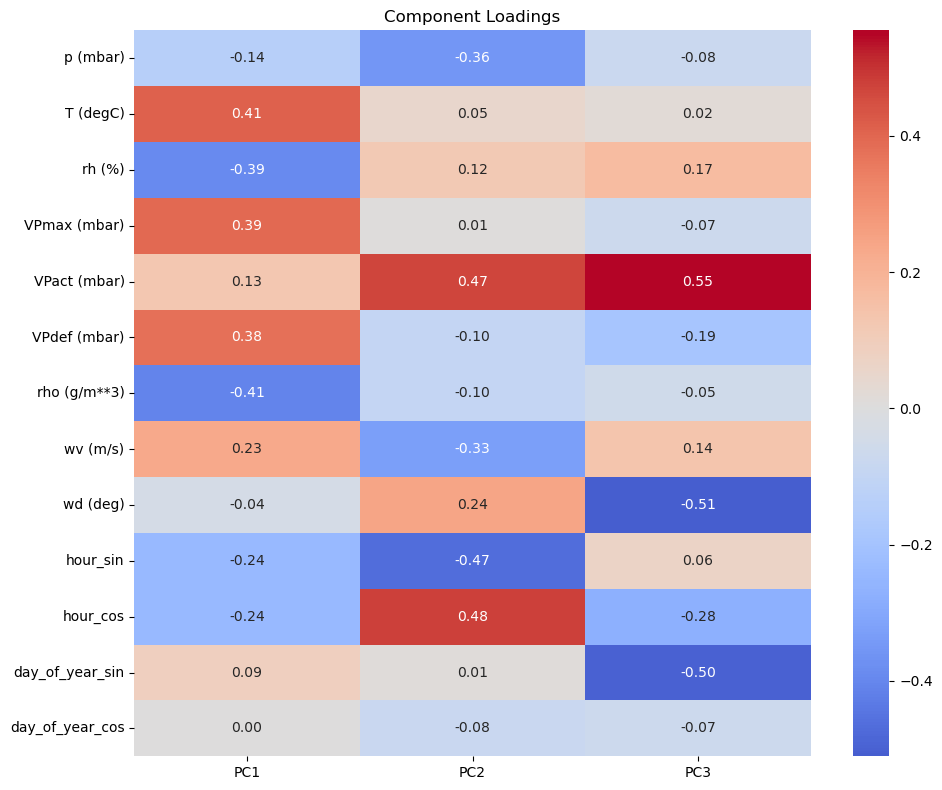

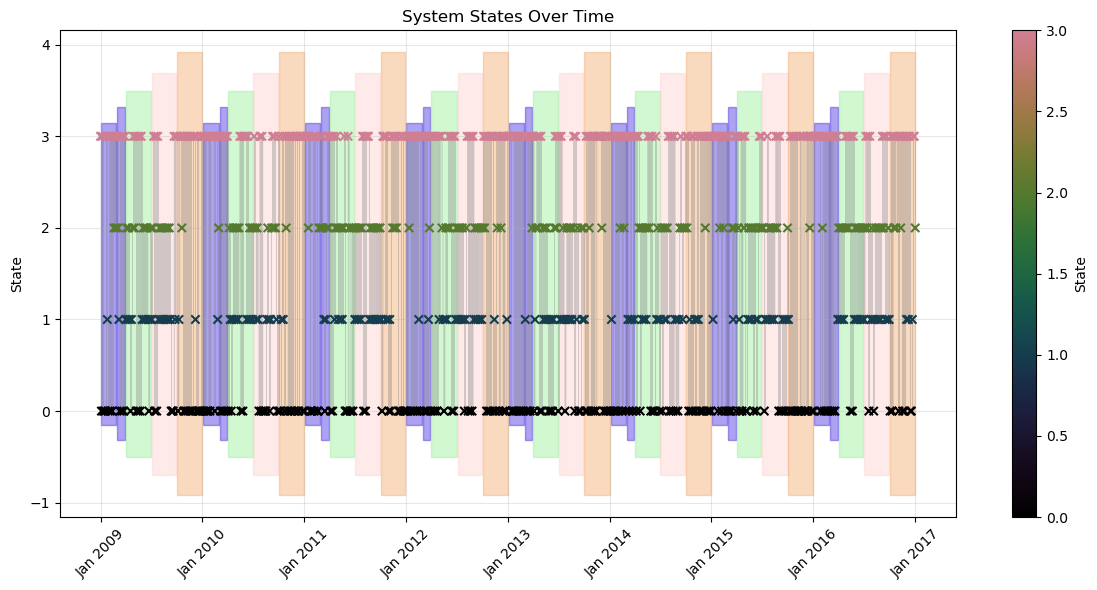

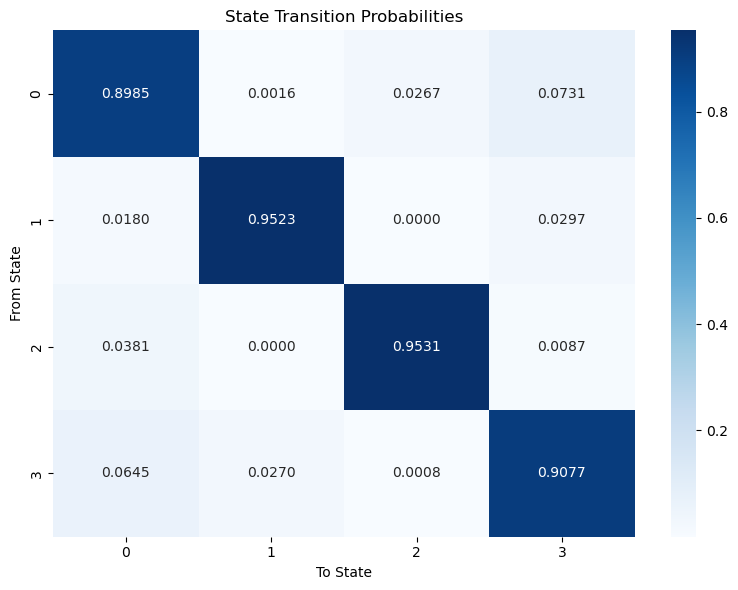

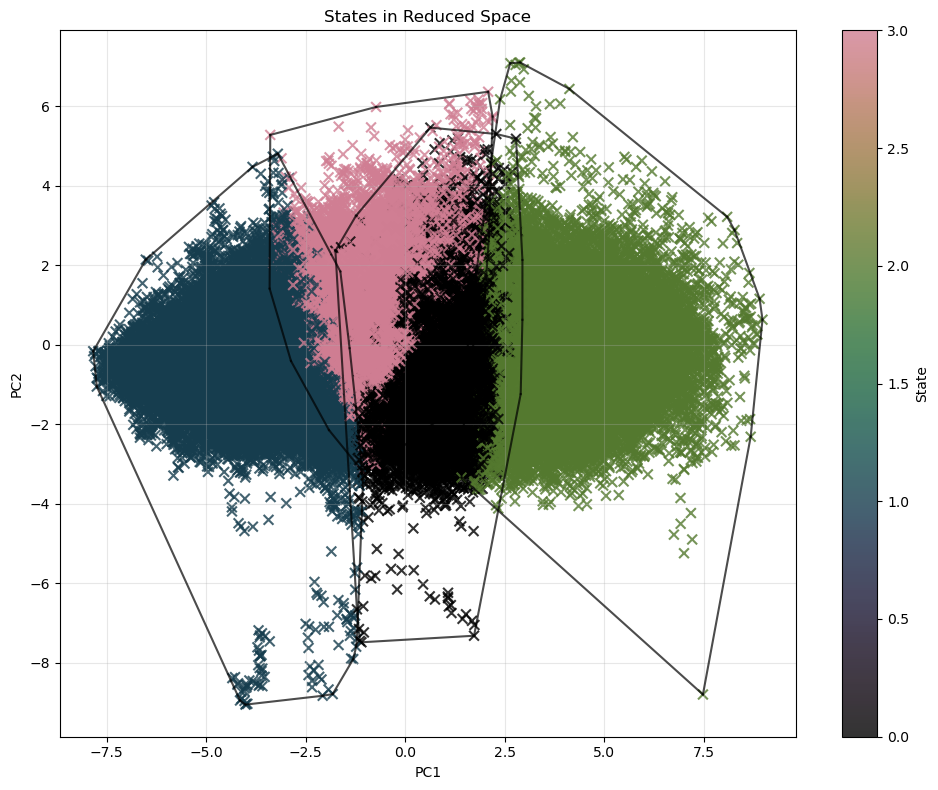

In [72]:
# Load data (using function from Task 1)
df = load_data('climate.csv')#.iloc[::100,:]
# outliers
df = df.apply(lambda col: col.mask((col - col.mean()).abs() / col.std() > 5, col.mean()))
# drop reduntant columns
df.drop(columns=["Tpot (K)", "Tdew (degC)",
                 "sh (g/kg)", "H2OC (mmol/mol)",
                 "max. wv (m/s)"], inplace=True)

method = 'pca'
# 1. Preprocess data
df_pre = preprocess_data(df)

# 2. Engineering features and removing seasonality
df_cleaned = engineer_features(df_pre)
df_with_features = remove_seasonality(df_cleaned, period=144)

# Standardize the data
if method == 'pca':
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df_with_features)
    scaled_df = pd.DataFrame(scaled_data, index=df_with_features.index, columns=df_with_features.columns)
else:
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df_with_features)
    scaled_df = pd.DataFrame(scaled_data, index=df_with_features.index, columns=df_with_features.columns)

# 3. Reduce dimensions
pc_df, loadings, explained_var = reduce_dimensions(scaled_df, 
                                                   n_components=3, method = method)
# 4. Sliding window analysis
window_df, windows = sliding_window_analysis(pc_df)

# 5. Component contribution analysis
rolling_var, dominant_component, dominance_counts, top_contributors = analyze_component_contributions(pc_df, loadings)

# 6. State transition detection
pc_df_with_states, transition_matrix, avg_durations = detect_states(pc_df)

# 7. Create visualizations
create_visualizations(pc_df, pc_df_with_states, loadings, explained_var, 
                     window_df, dominant_component, transition_matrix)

# 8. Save results to CSV files
# Save principal components with states
pc_df_with_states.to_csv('pc_with_states.csv')

# Save component loadings
if loadings is not None:
    loadings.to_csv('component_loadings.csv')

# Save transition matrix
pd.DataFrame(transition_matrix).to_csv('transition_matrix.csv')

# Save average state durations
pd.DataFrame.from_dict(avg_durations, orient='index', 
                      columns=['avg_duration']).to_csv('state_durations.csv')

# Save top contributors for each component
if top_contributors:
    pd.DataFrame.from_dict(top_contributors).to_csv('top_contributors.csv')

# Print summary of findings
print(f"Reduced data to {len(pc_df.columns)} components")
if explained_var is not None:
    print(f"Explained variance: {explained_var.sum():.2%}")
print(f"Detected {len(avg_durations)} states")
print(f"Average state durations: {avg_durations}")
print(f"Component dominance counts: {dominance_counts.to_dict()}")

### Discussion
<div style="text-align: justify"> 
The dimension reduction technique to apply in a particular case highly depends on the information that one aims to capture, e.g. global properties.
    
1. PCA
    1. It is good for capturing large-scale pattern analysis, e.g., identifying dominant climate: variability: seasons.  

1. t-SNE
    1. It is better for visualizing clusters of meteorological phenomena (e.g., extreme weather event classification

*Future Work:*

1. Investigating the impact of other techniques suggested by the literature for meteorological data e.g.  the Uniform Manifold Approximation (UMAP).2.  Hybrid methods, as suggested by C. Balsa et al.

*References:*
1. C. Balsa et al., "Reconstruction of Meteorological Records by Methods Based on Dimension Reduction of the Predictor Dataset" Computation, 11, 98 (2023).
</div>